# Estimate AO system throughput

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [2]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [3]:
from scipy.optimize import brentq
from scipy.optimize import fminbound
from scipy.signal import fftconvolve

In [137]:
R_approx = 0.97
N_mirrors = 7
R_M8 = 0.97 # deformable mirror reflectivity
R_M9 = 0.99 # dichroic mirror reflectivity 
R_M10 = 0.97

In [138]:
R_tot = (R_approx**N_mirrors) * R_M8 * R_M9
R_tot

0.775905925843319

## Approximate Strehl Ratio in H-band

In [6]:
def marechal_strehl(Strehl_ref, wavelength_ref, wavelength_observed): 
    """
    Calculate the Strehl ratio using Marechal's approximation.

    Parameters:
    Strehl_ref (float): The reference Strehl ratio at the reference wavelength.
    wavelength_ref (float): The reference wavelength (in the same units as wavelength_observed, metres).
    wavelength_observed (float): The observed wavelength (in the same units as wavelength_ref, metres). 

    Returns: 
    Strehl_observed (float): The estimated Strehl ratio at the observed wavelength.
    sigma_WFE (float): The wavefront error in radians at the observed wavelength.
    """

    # Calculate the wavefront error in physical units (meters), not a fraction of the wavelength
    sigma_WFE = wavelength_ref * np.sqrt(-np.log(Strehl_ref)) / (2 * np.pi) 

    # Calculate the Strehl ratio of the observed wavelength using Marechal's approximation
    Strehl_observed = np.exp(-(2 * np.pi * sigma_WFE / wavelength_observed)**2)

    return Strehl_observed, sigma_WFE

In [7]:
print("If the Strehl ratio at 2.2 microns is 0.7:")
print(f"Strehl ratio at H-band 1.5 microns = {marechal_strehl(0.7, 2.2e-6, 1.5e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.7 = {marechal_strehl(0.7, 2.2e-6, 1.5e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.7:
Strehl ratio at H-band 1.5 microns = 0.464
Wavefront error at S(2.2micron)~0.7 = 2.091e-07 metres


In [8]:
print("If the Strehl ratio at 2.2 microns is 0.6:")
print(f"Strehl ratio at H-band 1.5 microns = {marechal_strehl(0.6, 2.2e-6, 1.5e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.6 =  {marechal_strehl(0.6, 2.2e-6, 1.5e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.6:
Strehl ratio at H-band 1.5 microns = 0.333
Wavefront error at S(2.2micron)~0.6 =  2.503e-07 metres


In [9]:
print("If the Strehl ratio at 2.2 microns is 0.4:")
print(f"Strehl ratio at H-band 1.5 microns = {marechal_strehl(0.4, 2.2e-6, 1.5e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.4 = {marechal_strehl(0.4, 2.2e-6, 1.5e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.4:
Strehl ratio at H-band 1.5 microns = 0.139
Wavefront error at S(2.2micron)~0.4 = 3.352e-07 metres


In [10]:
print("If the Strehl ratio at 2.2 microns is 0.7:")
print(f"Strehl ratio at J-band 1.25 microns = {marechal_strehl(0.7, 2.2e-6, 1.25e-6)[0]:.3f}")
print(f"Wavefront error at S(2.2micron)~0.7 = {marechal_strehl(0.7, 2.2e-6, 1.25e-6)[1]:.3e} metres")

If the Strehl ratio at 2.2 microns is 0.7:
Strehl ratio at J-band 1.25 microns = 0.331
Wavefront error at S(2.2micron)~0.7 = 2.091e-07 metres


## Convolve the PSF with Jitter

Let's make an Airy function for the F=5/# image at focal plane. 

We then convolve that Airy function of the point source at diffraction limit with the jitter, which is expected to be 20 milliarcsecond root mean square. 

In [11]:
def diffraction_limited_E_field_at_fibre_2d(x, y, lam0, F_eff, alpha=0.0, E_S=1.0, decentre=None):
    """
    Diffraction-limited telescope image electric field evaluated
    on a 2D grid at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
        The fibre centre is assumed to be at x=0, y=0.
    lam0 : float
        Wavelength [m].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    alpha : float
        Central obstruction ratio.
    E_S : float
        Overall field amplitude.
    decentre : None or tuple
        If None, the image is centred on the fibre.
        If (dx, dy), the image centre is shifted by dx, dy [m]
        relative to the fibre centre.

    Returns
    -------
    E_image : 2D array
        Electric field at the fibre input plane.
    I_image : 2D array
        Intensity at the fibre input plane.
    """

    if decentre is None:
        dx, dy = 0.0, 0.0
        r_image = np.sqrt(x**2 + y**2)

    else:
        dx, dy = decentre
        # Coordinates relative to the centre of the image/PSF
        x_shifted = x - dx
        y_shifted = y - dy # if we set phi=0, the vertical shift would become zero as we 
        # later set dy=rsin(phi)=r, assuming the shift is purely radial

        # The radial distance from the centre of the PSF is calculated using the coordinates
        r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Compute s, the normalized radial coordinate in the image plane, which is used to calculate the Airy pattern.
    s = np.pi * r_image / (lam0 * F_eff)

    airy_term = np.divide(2 * j1(s), s, # Airy pattern term 2*J1(s)/s, which describes the diffraction pattern of a circular aperture.
        out=np.ones_like(s),
        where=s != 0   # to avoid division by zero at the centre of the PSF, where s=0. The limit of 2*j1(s)/s as s->0 is 1, which is consistent with the Airy pattern having a maximum value of 1 at the centre.
    )

    if alpha > 0:
        obstruction_term = np.divide(2 * j1(alpha * s), alpha * s,
            out=np.ones_like(s),
            where=(alpha * s) != 0   # to avoid division by zero at the centre of the PSF, where alpha * s = 0
        )
        E_image = E_S * (airy_term - alpha**2 * obstruction_term)
    else:
        E_image = E_S * airy_term

    I_image = np.abs(E_image)**2

    return E_image, I_image

In [12]:
core_radius_range_test = np.arange(2.5e-6, 30e-6 + 0.5e-6, 0.05e-6) # from 2 to 50 microns in meters, note arange is exclusive of the endpoint, so we add 0.5e-6 to include 30e-6 in the range
lam0 = 1.5e-6
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
alpha = 0.0
E_S = 1.0
D_tel = 8.0 # in meters
F_coude = 49.9
Magnification = F_fibre / F_coude # demagnification factor from the telescope focal plane to the fibre input plane

In [13]:
Magnification

np.float64(0.09969813999064328)

In [14]:
FWHM_diff_lim_arcsec = lam0 / D_tel * 206265 # in arcseconds, physical size of the diffraction-limited PSF at the primary focus
FWHM_diff_lim_coude = lam0 * F_coude # in meters, physical size of the diffraction-limited PSF at the coude focus (fibre input plane)
FWHM_diff_lim_demag = lam0 * F_fibre # in meters, physical size of the diffraction-limited PSF at the fibre input plane after demagnification
print(f"Diffraction-limited FWHM at the primary focus = {FWHM_diff_lim_arcsec:.3f} arcseconds")
print(f"Diffraction-limited FWHM at the coude focus (fibre input plane) = {FWHM_diff_lim_coude*1e6:.3f} microns")
print(f"Diffraction-limited FWHM at the fibre input plane after demagnification = {FWHM_diff_lim_demag*1e6:.3f} microns")

Diffraction-limited FWHM at the primary focus = 0.039 arcseconds
Diffraction-limited FWHM at the coude focus (fibre input plane) = 74.850 microns
Diffraction-limited FWHM at the fibre input plane after demagnification = 7.462 microns


In [15]:
# convert 0.3210966247040923 arcseconds size to physical size at the fibre input plane, where F_eff = F_fibre
seeing_FWHM_arcsec = 0.3210966247040923
seeing_rad = seeing_FWHM_arcsec / 206265.0
f_eff = F_fibre * D_tel 
FWHM_physical_1p5micron = f_eff * seeing_rad
print(f"Physical FWHM of the seeing disk at the fibre input plane = {FWHM_physical_1p5micron*1e6:.3f} microns")

Physical FWHM of the seeing disk at the fibre input plane = 61.957 microns


### Estimating the seeing-limited halo at ($1.5\,\mu\mathrm{m}$)

The seeing FWHM is scaled from the VLT White Book value of 0.4 arcsec at $500\,\mathrm{nm}$ using the Kolmogorov wavelength dependence

$$
\mathrm{FWHM}(\lambda)
=
\mathrm{FWHM}_0
\left(
\frac{\lambda}{\lambda_0}
\right)^{-1/5}.
$$

This is used to estimate the seeing at \(1.5\,\mu\mathrm{m}\). The corresponding Fried parameter is then calculated from

$$
r_0
\approx
0.98\frac{\lambda}{\mathrm{FWHM}},
$$

where the FWHM is converted from arcseconds to radians.

The estimated FWHM at \(1.5\,\mu\mathrm{m}\) is then used as the width of a Moffat profile to approximate the long-exposure seeing-limited halo. The Moffat profile will subsequently be used to construct an approximate halo electric-field distribution for the partial-AO fibre-coupling model.

In [16]:
# def seeing_limited_E_field_at_fibre_2d(): 
    

In [17]:
r_max = 125e-6
n_grid = 1000

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [18]:
# Seeing wavelength scaling:
# FWHM(lambda) = FWHM_ref * (lambda / lambda_ref)**(-1/5)

FWHM_ref_arcsec = 0.4       # seeing at the reference wavelength [arcsec]
lambda_ref = 0.5e-6         # reference wavelength [m]
lambda_obs = 1.5e-6         # observing wavelength [m]

# Scale the seeing FWHM from 0.5 microns to 1.5 microns
FWHM_1p5micron_arcsec = FWHM_ref_arcsec * (lambda_obs / lambda_ref)**(-1/5)

# Convert seeing FWHM from arcsec to radians
FWHM_1p5micron_rad = FWHM_1p5micron_arcsec / 206265.0

# Estimate the Fried parameter using:
# FWHM ≈ 0.98 * lambda / r0
# r0 = 0.98 * lambda / FWHM

r0_1p5micron = 0.98 * (lambda_obs / FWHM_1p5micron_rad)

print(f"Seeing FWHM at 1.5 microns: {FWHM_1p5micron_arcsec:.5f} arcsec")
print(f"Fried parameter at 1.5 microns: {r0_1p5micron:.5f} m") 

Seeing FWHM at 1.5 microns: 0.32110 arcsec
Fried parameter at 1.5 microns: 0.94429 m


In [19]:
FWHM_1p5micron_arcsec

0.3210966247040923

In [20]:
FWHM_1p5micron_rad

1.5567189038571367e-06

In [21]:
def moffat_halo_intensity_at_fibre_2d(
        x,
        y,
        seeing_FWHM_arcsec,
        F_eff,
        D_tel,
        beta=4.765, # turbulence induced seeing
        amplitude=1.0,
        decentre=None,
):
    """
    Seeing-limited Moffat profile evaluated on a 2D grid
    at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
    seeing_fwhm_arcsec : float
        Seeing FWHM at the observing wavelength [arcsec].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    D_tel : float
        Telescope diameter [m].
    beta : float
        Moffat wing parameter.
    E_S : float
        Overall field-amplitude scaling.
    decentre : None or tuple
        Shift of the Moffat-profile centre [m].

    Returns
    -------
    E_halo : 2D array
        Approximate halo electric-field amplitude.
    I_halo : 2D array
        Moffat intensity profile.
    """

    if beta <= 1: 
        raise ValueError("Moffat beta parameter must be greater than 1 for a physical profile with finite total flux.")
    
    if decentre is None: 
        dx, dy = 0.0, 0.0
    else: 
        dx, dy = decentre
    
    x_shifted = x - dx 
    y_shifted = y - dy 
    # The radial distance from the centre of the Moffat profile is calculated using the shifted coordinates
    r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Convert the angular seeing FWHM into a physical width at the input focal plane 
    seeing_rad = seeing_FWHM_arcsec / 206265.0
    # effective focal length used after re-imaging
    f_eff = F_eff * D_tel 
    # Calculate the physical size of the seeing disk at the focal plane using the effective focal length 
    # and the angular size of the seeing, y=f_eff*tan(theta)~f_eff*theta for small angles, so FWHM_physical = f_eff * seeing_rad
    # This is the relation where the size of the image is affected by the focal length and angular size of the substended angle (seeing)
    FWHM_physical = f_eff * seeing_rad

    # Convert Moffat FWHM to its radial scale parameter. 
    alpha_moffat = FWHM_physical / (2.0 * np.sqrt(2**(1/beta) - 1))

    # Calculate the Moffat intensity profile
    I_halo = (1 + (r_image / alpha_moffat)**2)**(-beta)

    # Normalize the Moffat profile so that its peak intensity is equal to the specified amplitude
    I_halo_norm = amplitude * I_halo / np.max(I_halo)

    # The electric field amplitude is the square root of the intensity
    E_halo_norm = np.sqrt(I_halo_norm) # Note this approximate assigns flat phase to the entire halo

    return E_halo_norm, I_halo_norm

In [22]:
def normalize_intensity_2d(I, x, y):
    dx = x[0, 1] - x[0, 0]
    dy = y[1, 0] - y[0, 0]

    total_power = np.sum(I) * dx * dy

    if total_power <= 0:
        raise ValueError("Intensity must have positive total power.")

    return I / total_power

In [23]:
def gaussian_jitter_kernel_2d(x, y, jitter_rms_mas, F_eff, D_tel): 
    """
    Normalized 2D Gaussian kernel representing the residual tip-tilt jitter of the PSF at the fibre input plane.

    Parameters 
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m]. 
    jitter_rms_mas : float
        One axis Gaussian RMS tip-tilt jitter in milliarcseconds.
    F_eff : float
        Effective focal ratio at the fibre front.
    D_tel : float
        Diameter of the telescope primary mirror [m]. 

    Returns: 
    -------
    kernel : 2D array
        Normalized Gaussian kernel representing the tip-tilt jitter in the focal plane.
    sigma_jitter : float
        The standard deviation of the Gaussian jitter in meters at the focal plane.
    """

    # Conert jitter from milliarcseconds to radians
    jitter_rms_arcsec = jitter_rms_mas / 1000.0
    jitter_rms_rad = jitter_rms_arcsec / 206265.0

    f_eff = F_eff * D_tel
    # Convert the angular jitter to a physical jitter at the focal plane
    sigma_jitter = f_eff * jitter_rms_rad

    # r2 is the squared radial distance from the centre of the PSF in the focal plane, calculated using the x and y coordinates
    r2 = x**2 + y**2 

    # Two-dimensional Gaussian jitter distribution
    kernel = np.exp(-r2 / (2.0 * sigma_jitter**2))

    # Normalize the kernel to unit integrated area
    kernel = normalize_intensity_2d(
        kernel,
        x,
        y,
    )

    return kernel, sigma_jitter
    

In [24]:
def gaussian_jitter_kernel_amplitude_factor_2d(x, y, jitter_rms_mas, F_eff, D_tel): 
    """
    Normalized 2D Gaussian kernel representing the residual tip-tilt jitter of the PSF at the fibre input plane.

    Parameters 
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m]. 
    jitter_rms_mas : float
        One axis Gaussian RMS tip-tilt jitter in milliarcseconds.
    F_eff : float
        Effective focal ratio at the fibre front.
    D_tel : float
        Diameter of the telescope primary mirror [m]. 

    Returns: 
    -------
    kernel : 2D array
        Normalized Gaussian kernel representing the tip-tilt jitter in the focal plane.
    sigma_jitter : float
        The standard deviation of the Gaussian jitter in meters at the focal plane.
    """

    # Conert jitter from milliarcseconds to radians
    jitter_rms_arcsec = jitter_rms_mas / 1000.0
    jitter_rms_rad = jitter_rms_arcsec / 206265.0

    f_eff = F_eff * D_tel
    # Convert the angular jitter to a physical jitter at the focal plane
    # sigma_jitter_amp_factored = np.sqrt(2) * f_eff * jitter_rms_rad
    sigma_jitter_amp_factored = 2.0 * f_eff * jitter_rms_rad


    # sigma_jitter = f_eff * jitter_rms_rad
    # sigma_jitter_amp_factored = sigma_jitter**2

    # r2 is the squared radial distance from the centre of the PSF in the focal plane, calculated using the x and y coordinates
    r2 = x**2 + y**2 

    # Two-dimensional Gaussian jitter distribution
    kernel = np.exp(-r2 / (2.0 * sigma_jitter_amp_factored**2))

    # Normalize the kernel to unit integrated area
    kernel = normalize_intensity_2d(
        kernel,
        x,
        y,
    )

    return kernel, sigma_jitter_amp_factored

In [25]:
np.sqrt(1/2)

np.float64(0.7071067811865476)

In [26]:
np.sqrt(2* np.log(2))*2

np.float64(2.3548200450309493)

In [27]:
# Convolve the airy intensity with the jitter Gaussian kernel

# Generate the diffraction-limited Airy field and intensity
E_airy, I_airy = diffraction_limited_E_field_at_fibre_2d(
    x=x,
    y=y,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha,
    E_S=E_S,
)

# Normalize the Airy intensity to unit integrated power
I_airy_norm = normalize_intensity_2d(
    I_airy,
    x,
    y,
)

# Generate the normalized Gaussian jitter kernel
jitter_kernel, sigma_jitter = gaussian_jitter_kernel_2d(
    x=x,
    y=y,
    jitter_rms_mas=20.0,
    F_eff=F_fibre,
    D_tel=8.0,
)

# Pixel dimensions at the fibre input plane
dx = x[0, 1] - x[0, 0]
dy = y[1, 0] - y[0, 0]

# Convolve the Airy intensity with the jitter distribution
I_core_jittered = fftconvolve(
    I_airy_norm,
    jitter_kernel,
    mode="same",
) * dx * dy

# Normalize after convolution to account for numerical edge effects
I_core_jittered_norm = normalize_intensity_2d(
    I_core_jittered,
    x,
    y,
)

print(
    f"Jitter RMS at the fibre plane: "
    f"{sigma_jitter * 1e6:.3f} microns"
)

print(
    f"Integrated jittered-core power: "
    f"{np.sum(I_core_jittered_norm) * dx * dy:.6f}"
)

Jitter RMS at the fibre plane: 3.859 microns
Integrated jittered-core power: 1.000000


In [28]:
# fftconvolve?

In [29]:
I_airy_norm = normalize_intensity_2d(I_airy, x, y)

jitter_kernel, sigma_jitter = gaussian_jitter_kernel_2d(
    x=x, y=y, 
    jitter_rms_mas = 20.0, 
    F_eff=F_fibre, 
    D_tel=8.0
)

dx = x[0, 1] - x[0, 0]
dy = y[1, 0] - y[0, 0]

# Convolve the diffraction limited Airy pattern with the Gaussian jitter kernel to get the 
# jitter-convolved PSF core intensity at the fibre input plane. The convolution is done using 
# fftconvolve for efficiency, and we multiply by dx*dy to account for the pixel area in the 
# convolution.
I_core_jittered = fftconvolve(I_airy_norm, jitter_kernel, mode='same') * dx * dy

I_core_jittered_norm = normalize_intensity_2d(I_core_jittered, x, y)


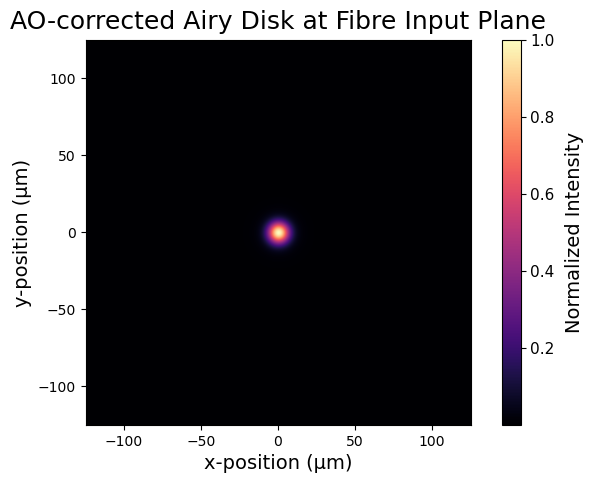

In [93]:
plt.figure(figsize=(8, 5))
plt.imshow(I_core_jittered_norm / I_core_jittered_norm.max(), cmap='magma', extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6))
plt.xlabel("x-position (μm)", fontsize=14)
plt.ylabel("y-position (μm)", fontsize=14)
# plt.ylabel("Halo intensity (normalized to unit integrated power)")
plt.title("AO-corrected Airy Disk at Fibre Input Plane", fontsize=18, pad=8) # move the title higher to avoid overlap with the colorbar

# plt.colorbar(label="Normalized Halo Intensity") # fontsize=14
cbar = plt.colorbar()
cbar.set_label("Normalized Intensity", fontsize=14, labelpad=7) # move the colorbar label away from the colorbar
cbar.ax.tick_params(labelsize=11)  # Set colorbar tick label size   
# plt.grid(alpha=0.3)
# plt.show()

### Approximating the diffraction-limited electric field with residual jitter

The diffraction-limited Airy electric field is convolved with a normalized two-dimensional Gaussian jitter kernel. The Gaussian represents the assumed probability distribution of residual image motion, with an RMS width of \(20\) mas.

The convolved field is

$$
\overline{E}(x,y)
=
\iint
E_{\mathrm{Airy}}(x-\Delta x,y-\Delta y)\,
G(\Delta x,\Delta y)\,
d\Delta x\,d\Delta y,
$$

where \(G(\Delta x,\Delta y)\) is the normalized Gaussian jitter distribution.

This convolution can be interpreted as a weighted average of shifted Airy electric-field profiles. Each possible displacement is weighted by its probability of occurring under the assumed Gaussian jitter.

The factor

$$
\Delta x\,\Delta y
$$

is included in the numerical convolution because the continuous two-dimensional integral is approximated by a discrete sum over the grid.

Since the convolution is applied directly to the signed Airy electric field, the positive and negative field amplitudes associated with the alternating Airy rings are retained. The Gaussian jitter smooths the field spatially, reducing the peak amplitude and weakening the outer oscillations.

The result is therefore an approximate Gaussian-averaged coherent electric field:

$$
\overline{E}
=
E_{\mathrm{Airy}} * G_{\mathrm{jitter}}.
$$

For plotting, the convolved field is peak-normalized using

$$
E_{\mathrm{plot}}
=
\frac{\overline{E}}
{\max\left(|\overline{E}|\right)}.
$$

For a fibre overlap integral, the field should instead be normalized by its integrated optical power:

$$
E_{\mathrm{norm}}
=
\frac{\overline{E}}
{\sqrt{\iint |\overline{E}(x,y)|^2\,dx\,dy}}.
$$

This model provides a simplified approximation of how residual pointing jitter smooths the coherent diffraction-limited electric-field profile before coupling into the fibre.

In [30]:
jitter_kernel_factored, sigma_jitter_factored = gaussian_jitter_kernel_amplitude_factor_2d(x, y, 20, F_fibre, D_tel)

In [31]:
E_core_jittered = fftconvolve(E_airy, jitter_kernel_factored, mode='same') * dx * dy

# E_core_jittered = fftconvolve(E_airy, jitter_kernel, mode='same') * dx * dy

E_core_jittered_norm = E_core_jittered / np.max(E_core_jittered)

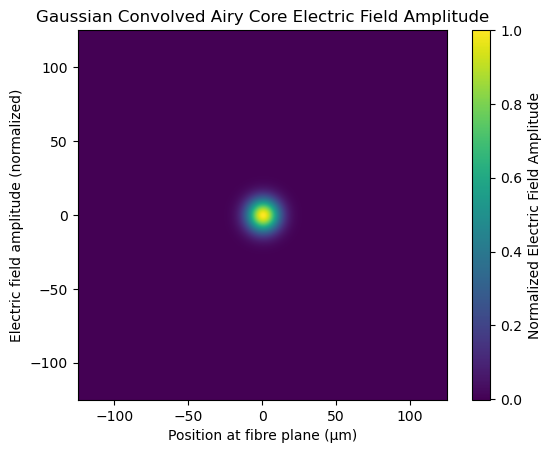

In [32]:
plt.imshow(E_core_jittered_norm, extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6))
plt.xlabel("Position at fibre plane (μm)")
plt.ylabel("Electric field amplitude (normalized)")
plt.title("Gaussian Convolved Airy Core Electric Field Amplitude")
plt.colorbar(label="Normalized Electric Field Amplitude")
# plt.grid(alpha=0.3)
plt.show()

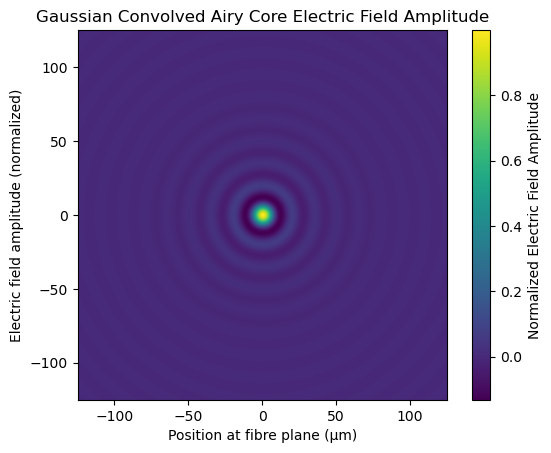

In [33]:
plt.imshow(E_airy, extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6))
plt.xlabel("Position at fibre plane (μm)")
plt.ylabel("Electric field amplitude (normalized)")
plt.title("Gaussian Convolved Airy Core Electric Field Amplitude")
plt.colorbar(label="Normalized Electric Field Amplitude")
# plt.grid(alpha=0.3)
plt.show()

In [34]:
# Step 4: Generate the seeing-limited Moffat halo

# Generate the peak-normalized Moffat seeing halo
E_halo_approx, I_halo_peak_norm = (
    moffat_halo_intensity_at_fibre_2d(
        x=x,
        y=y,
        seeing_FWHM_arcsec=FWHM_1p5micron_arcsec,
        F_eff=F_fibre,
        D_tel=8.0,
        beta=4.765,
        amplitude=1.0,
        decentre=None,
    )
)

# Convert the halo to unit integrated power
I_halo_power_norm = normalize_intensity_2d(
    I_halo_peak_norm,
    x,
    y,
)

print(
    f"Integrated halo power: "
    f"{np.sum(I_halo_power_norm) * dx * dy:.6f}"
)

Integrated halo power: 1.000000


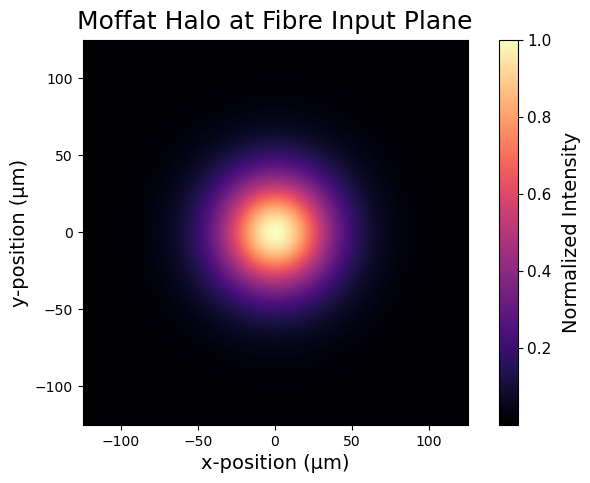

In [94]:
plt.figure(figsize=(8, 5))
plt.imshow(I_halo_power_norm / I_halo_power_norm.max(), cmap='magma', extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6))
plt.xlabel("x-position (μm)", fontsize=14)
plt.ylabel("y-position (μm)", fontsize=14)
# plt.ylabel("Halo intensity (normalized to unit integrated power)")
plt.title("Moffat Halo at Fibre Input Plane", fontsize=18, pad=8) # move the title higher to avoid overlap with the colorbar

# plt.colorbar(label="Normalized Halo Intensity") # fontsize=14
cbar = plt.colorbar()
cbar.set_label("Normalized Intensity", fontsize=14, labelpad=7) # move the colorbar label away from the colorbar
cbar.ax.tick_params(labelsize=11)  # Set colorbar tick label size   
# plt.grid(alpha=0.3)
# plt.show()

In [35]:
# # Normalize the jitter-convolved Airy core to unit integrated power

# core_total_power = np.sum(I_core_jittered) * dx * dy

# if core_total_power <= 0:
#     raise ValueError("The jitter-convolved Airy core has zero or negative total power.")

# I_core_jittered_power_norm = I_core_jittered / core_total_power

In [36]:
def partial_AO_PSF_intensity_2d(I_core_jittered, I_halo, x, y, strehl): 
    """
    Combine a jitter-broadened diffraction-limited core and
    a seeing-limited Moffat halo.

    Parameters
    ----------
    strehl : float
        Fraction of the normalized PSF power assigned to the
        corrected core in this simplified model.
    I_core_jittered : 2D array
        Intensity of the jitter-broadened diffraction-limited core, normalized to unit integrated power.
    I_halo : 2D array
        Intensity of the seeing-limited Moffat halo, normalized to unit integrated power.
    """
    if not 0.0 <= strehl <= 1.0: 
        raise ValueError("Strehl ratio must be between 0 and 1.")

    # The jittered core is the AO-corrected part of the PSF
    I_core_jittered_norm = normalize_intensity_2d(I_core_jittered, x, y)
    
    # The halo is the uncorrected part of the PSF
    I_halo_norm = normalize_intensity_2d(I_halo, x, y)

    # I_psf_tot= S*I_psf_corrected + (1 - S) * I_halo
    I_AO_final = strehl * I_core_jittered_norm + (1 - strehl) * I_halo_norm

    I_AO_final_norm = normalize_intensity_2d(I_AO_final, x, y)

    return I_AO_final_norm


In [37]:
# # Step 5: Construct the simplified partial-AO PSF

# if not 0.0 <= strehl_H <= 1.0: 
#     raise ValueError("Strehl ratio must be between 0 and 1.")

In [38]:
strehl_H = 0.464

# The intensity is the added combination I_psf_tot= S*I_psf_corrected + (1 - S) * I_halo, 
# where the corrected core is represented by the jitter-convolved Airy pattern, and the 
# uncorrected halo is represented by the Moffat profile. Both components are normalized to 
# unit integrated power before combining, and the final combined PSF is also normalized 
# to unit integrated power to ensure it represents a valid intensity distribution. 

I_AO_final = partial_AO_PSF_intensity_2d(
    I_core_jittered=I_core_jittered_norm,
    I_halo=I_halo_power_norm,
    x=x,
    y=y,
    strehl=strehl_H,
)

print(
    f"Integrated partial-AO PSF power: "
    f"{np.sum(I_AO_final) * dx * dy:.6f}"
)

Integrated partial-AO PSF power: 1.000000


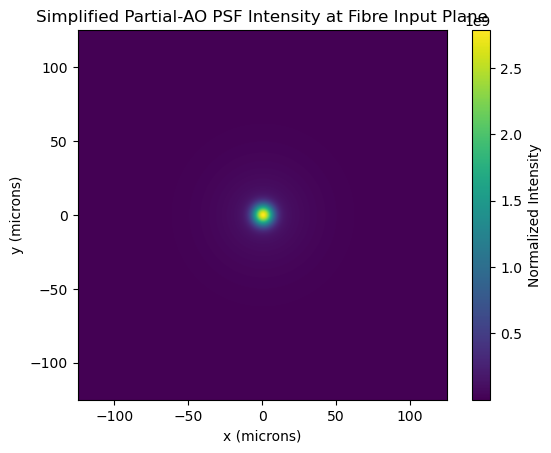

In [39]:
plt.imshow(I_AO_final, extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6), origin='lower')
plt.xlabel('x (microns)')
plt.ylabel('y (microns)')
plt.title('Simplified Partial-AO PSF Intensity at Fibre Input Plane')
plt.colorbar(label='Normalized Intensity')

In [40]:
# Find the grid indices nearest to x = 0 and y = 0
centre_x_index = np.argmin(np.abs(x[0, :]))
centre_y_index = np.argmin(np.abs(y[:, 0]))

# Physical x-coordinate through the centre of the PSF
x_1d = x[centre_y_index, :]

# Take a horizontal slice through y = 0
I_AO_1d = I_AO_final[centre_y_index, :]

# Approximate electric-field amplitude
E_AO_amplitude_1d = np.sqrt(
    np.clip(I_AO_1d, 0.0, None)
)

# Normalize only for visual comparison
I_AO_1d_plot = I_AO_1d / np.max(I_AO_1d)
E_AO_1d_plot = E_AO_amplitude_1d / np.max(E_AO_amplitude_1d)

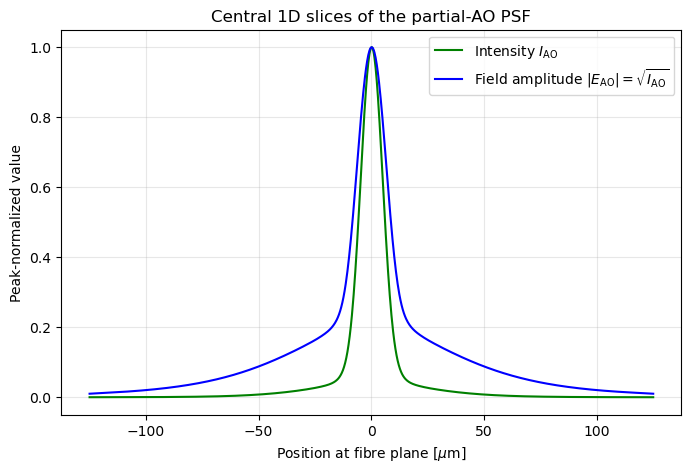

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_1d * 1e6,
    I_AO_1d_plot, color='green', 
    label=r"Intensity $I_{\rm AO}$",
)

plt.plot(
    x_1d * 1e6,
    E_AO_1d_plot, color='blue',
    label=r"Field amplitude $|E_{\rm AO}| = \sqrt{I_{\rm AO}}$",
)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized value")
plt.title("Central 1D slices of the partial-AO PSF")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\ '
<>:33: SyntaxWarning: invalid escape sequence '\ '
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_3959/1809118103.py:33: SyntaxWarning: invalid escape sequence '\ '
  plt.axvline(FWHM_diff_lim_demag / 2 * 1e6, color='gray', linestyle='--', label="FWHM$_{Airy\ function}$ (F=5/#)")


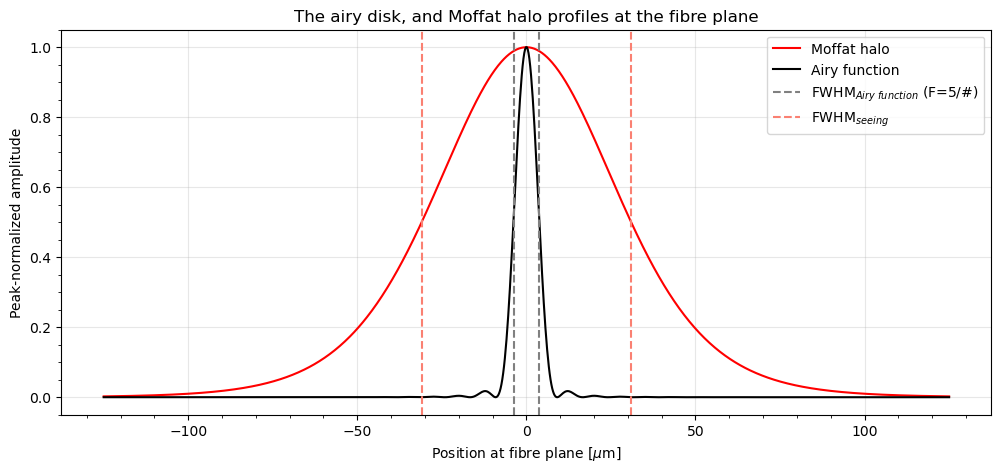

In [42]:
# I_airy_disk_1d = I_airy_norm[centre_y_index, :]
E_airy_disk_1d = E_airy[centre_y_index, :]
E_airy_disk_plot = E_airy_disk_1d / np.max(E_airy_disk_1d)
I_airy_disk_1d = I_airy_norm[centre_y_index, :]
I_airy_disk_plot = I_airy_disk_1d / np.max(I_airy_disk_1d)

I_halo_1d = I_halo_power_norm[centre_y_index, :]
I_halo_1d_plot = I_halo_1d / np.max(I_halo_1d)
E_halo_1d = np.sqrt(np.clip(I_halo_1d, 0.0, None))
E_halo_plot = E_halo_1d / np.max(E_halo_1d)

Gauss_jitter = jitter_kernel[centre_y_index, :]
Gauss_jitter_plot = Gauss_jitter / np.max(Gauss_jitter)

plt.figure(figsize=(12, 5))

plt.plot(
    x_1d * 1e6,
    I_halo_1d_plot, color='red',
    label="Moffat halo",
)
plt.plot(
    x_1d * 1e6,
    I_airy_disk_plot, color='k',
    label="Airy function",
)
# plt.plot(
#     x_1d * 1e6,
#     Gauss_jitter_plot, color='green',
#     label="Jittered Gaussian",
# )

plt.axvline(FWHM_diff_lim_demag / 2 * 1e6, color='gray', linestyle='--', label="FWHM$_{Airy\ function}$ (F=5/#)")
plt.axvline(-FWHM_diff_lim_demag / 2 * 1e6, color='gray', linestyle='--')

plt.axvline(FWHM_physical_1p5micron / 2 * 1e6, color='salmon', linestyle='--', label="FWHM$_{seeing}$")
plt.axvline(-FWHM_physical_1p5micron / 2 * 1e6, color='salmon', linestyle='--')

# Add minor ticks 
plt.minorticks_on()

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized amplitude")
plt.title("The airy disk, and Moffat halo profiles at the fibre plane")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

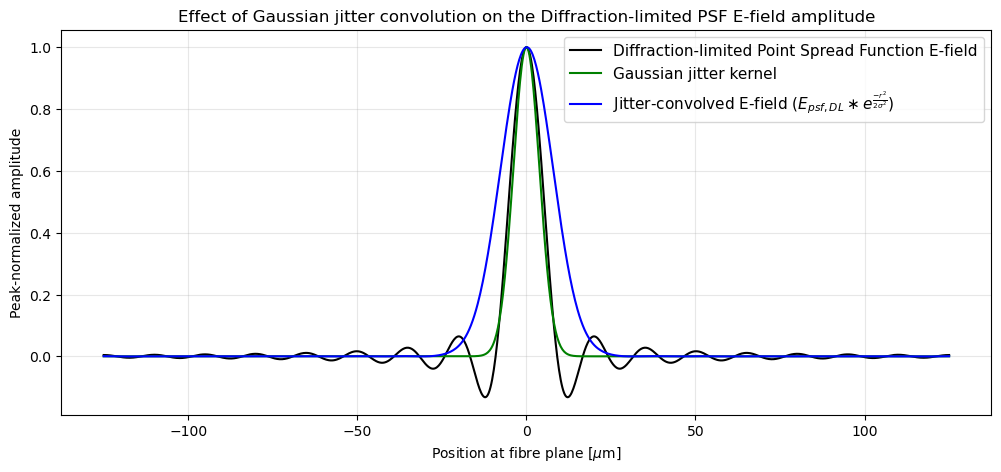

In [43]:
E_core_jittered_1d = E_core_jittered[centre_y_index, :]
E_core_jittered_plot = E_core_jittered_1d / np.max(E_core_jittered_1d)

plt.figure(figsize=(12, 5))

plt.plot(
    x_1d * 1e6,
    E_airy_disk_plot, color='k',
    label="Diffraction-limited Point Spread Function E-field",
)

plt.plot(
    x_1d * 1e6,
    Gauss_jitter_plot, color='green',
    label="Gaussian jitter kernel",
)

plt.plot(
    x_1d * 1e6,
    E_core_jittered_plot, color='blue',
    label="Jitter-convolved E-field ($E_{psf,DL} \\ast e^{\\frac{-r^2}{2\\sigma^2}})$",
)


plt.title("Effect of Gaussian jitter convolution on the Diffraction-limited PSF E-field amplitude")
plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized amplitude")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.show()

In [44]:
np.min(E_core_jittered_plot)

np.float64(-0.0005087376202115997)

In [45]:
FWHM_diff_lim_demag

np.float64(7.46240577829965e-06)

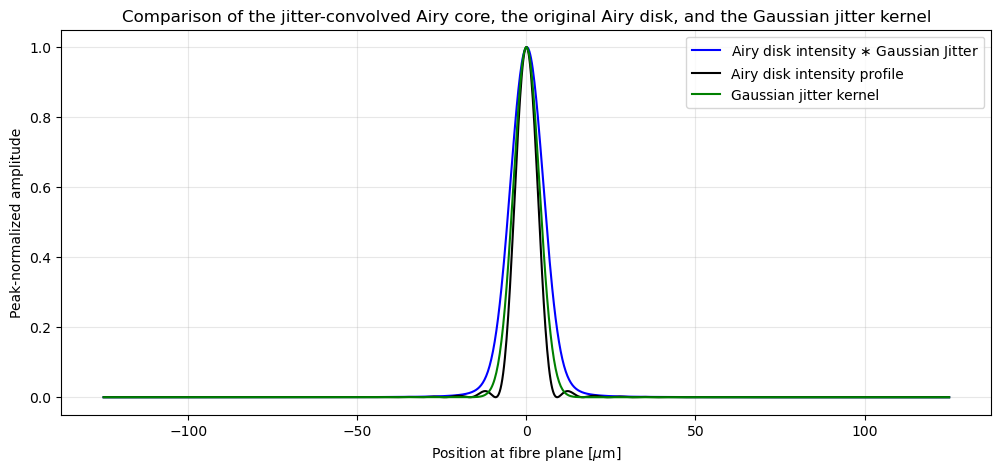

In [46]:
# Central slices
I_core_1d = I_core_jittered_norm[centre_y_index, :]
I_AO_1d = I_AO_final[centre_y_index, :]

# Convert to approximate amplitudes
E_core_1d = np.sqrt(np.clip(I_core_1d, 0.0, None))
E_AO_1d = np.sqrt(np.clip(I_AO_1d, 0.0, None))

# Normalize each profile by its own maximum for comparing shapes
I_core_plot = I_core_1d / np.max(I_core_1d)
I_AO_plot = I_AO_1d / np.max(I_AO_1d)
E_core_plot = E_core_1d / np.max(E_core_1d)

E_AO_plot = E_AO_1d / np.max(E_AO_1d)

plt.figure(figsize=(12, 5))

plt.plot(
    x_1d * 1e6,
    I_core_plot, color='blue',
    label="Airy disk intensity $\\ast$ Gaussian Jitter",
)

plt.plot(
    x_1d * 1e6,
    I_airy_disk_plot, color='black',
    label="Airy disk intensity profile",
)

# plt.plot(
#     x_1d * 1e6,
#     E_AO_plot,
#     label="Combined partial-AO profile",
#     linewidth=2,
# )

plt.plot(
    x_1d * 1e6,
    Gauss_jitter_plot, color='green',
    label="Gaussian jitter kernel",
)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized amplitude")
plt.title("Comparison of the jitter-convolved Airy core, the original Airy disk, and the Gaussian jitter kernel")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

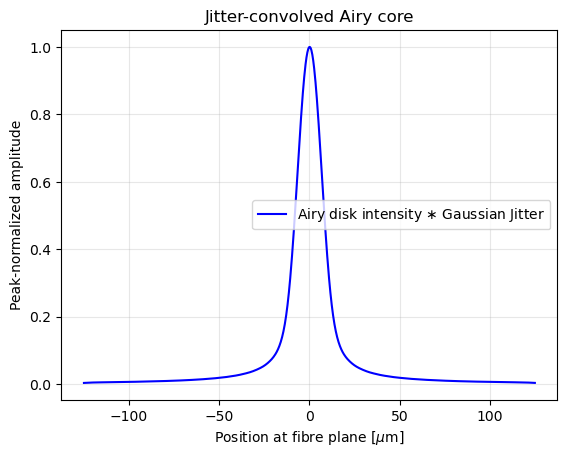

In [47]:
plt.plot(
    x_1d * 1e6,
    E_core_plot, color='blue',
    label="Airy disk intensity $\\ast$ Gaussian Jitter",
)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized amplitude")
plt.title("Jitter-convolved Airy core")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [48]:
I_jittered_test = np.abs(E_core_jittered)**2
I_jittered_test_norm = normalize_intensity_2d(I_jittered_test, x, y)
I_jittered_test_1d = I_jittered_test_norm[centre_y_index, :]
I_jittered_test_1d_plot = I_jittered_test_1d / np.max(I_jittered_test_1d)

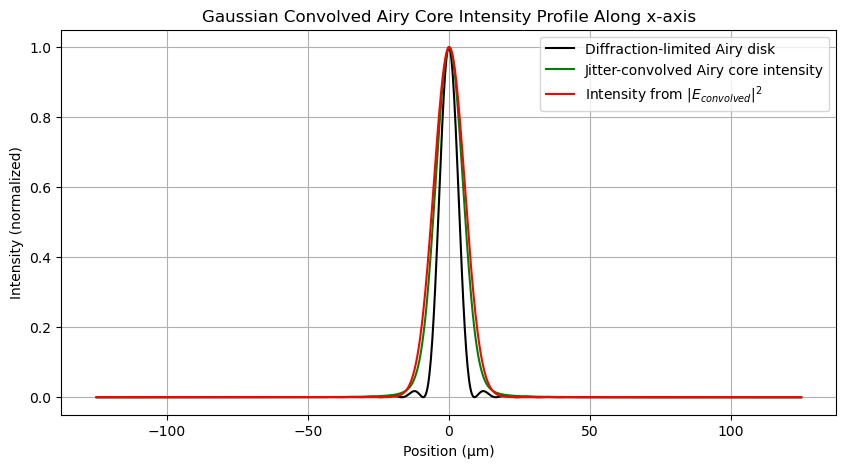

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(x_1d * 1e6, I_airy_disk_plot, color='black', label="Diffraction-limited Airy disk")
plt.plot(x_1d * 1e6, I_core_plot, color='green', label="Jitter-convolved Airy core intensity")
plt.plot(x_1d * 1e6, I_jittered_test_1d_plot, color='red', label="Intensity from $|E_{convolved}|^2$")  # Convert x_1d to micrometers for better visualization

plt.xlabel("Position (μm)")
plt.ylabel("Intensity (normalized)")
plt.title("Gaussian Convolved Airy Core Intensity Profile Along x-axis")
plt.grid(True)
plt.legend()

## Coupling Efficiency

In [50]:
def cutoff(l,m):
    """
    Utility  function which calculates the cutoff frequency Vc, and returns the normalised frequency (V) at cutoff V for
    a given mode l,m. 
    
    Arguments: 
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    
    Return value: 

    Vc: Normalised frequency at cutoff for the given mode, equals to the last zero of J_{l-1} for l>=1, 
    and Vc=0 for J_{m-1} for l=0.
    
    """

    if l >= 1: 
        Vc = jn_zeros(l - 1, m)[-1] # jn_zeros computes zeros of integer-order Bessel functions Jn. 
        return Vc # returns cutoff frequency of the mode (LP_lm with l>=1)
    elif l == 0: 
        if m == 1: 
            Vc = 0
            return Vc # returns cutoff frequency of the fundamental mode (LP01)
        else:
            Vc = jn_zeros(1, m - 1)[-1]
            return Vc # returns cutoff frequency of higher order modes (LP0m with m>1)
    else:
        raise ValueError("l must be >= 0")
    
def modes(V, l_max=5, m_max=5, v_margin=2e-3, az_sym_only=True): 
    """
    For each value of l, calculate the allowed values of m (if any). 
    Returns a list of modes that are supported by the fibre, sorted by their cutoff V-number.

    Arguments: 
    V: Normalised frequency of the fiber, float > 0
    l_max: Maximum azimuthal order to consider, integer >= 0
    m_max: Maximum radial order to consider, integer >= 1
    v_margin: Margin for checking mode existence at cutoff, to account for numerical precision issues. 
    az_sym_only: If True, only include modes with l=0 (azimuthally symmetric modes). If False, include all modes up to l_max. 
    
    Return value: 
    mode_list: A list of [l, m, Vc] for each mode that is supported by the fibre, where Vc is the cutoff V-number for that mode. 
    """ 
    if V <= 0: 
        raise ValueError("V must be >= 0")

    mode_list = []

    # loop over a range from l=0 to l_max, and for each l, loop over m=1 to m_max.
    for l in range(l_max + 1): 
        # if both conditions are met, we only consider modes with l=0, which are azimuthally symmetric.
        if az_sym_only and l != 0: 
            continue # skip modes with l != 0 if az_sym_only is True
        # no else needed, we just continue to the next l if the condition is met. if az_sym_only is False, we will consider all l values up to l_max, 
        # including those with l != 0.
        for m in range(1, m_max + 1): 
            V_c = cutoff(l, m) # calculate cutoff V-number for the mode (l,m)

            if V > V_c + v_margin: 
                mode_list.append([l, m, V_c])

            else: 
                break
    
    # A lambda function is an anonymous function in Python, which can take any number of arguments but can only have one expression. 
    # In this case, the lambda function is used as the key for sorting the mode_list. 
    mode_list.sort(key=lambda mode: mode[2])  # Sort by cutoff V-number

    return mode_list 

def function_characteristic_eq(X, V, l): 
    """
    Function that equates to zero at the roots of the characteristic equation. 

    Arguments: 
    X: Normalised transverse propagation constant in the core, float > 0
    V: Normalised frequency of the fibre, float > 0
    Return value: 
    lhs - rhs: The difference between the left-hand side and right-hand side of the characteristic equation, which should be zero at the roots. 
    """
    # Calculate Y based on the relationship Y^2 = V^2 - X^2
    Y = np.sqrt(V**2 - X**2) # Y is the normalised transverse propagation constant in the cladding, and must be real for guided modes (X < V)

    if l > 0: 
        lhs = X * jv(l + 1, X) / jv(l, X)
        rhs = Y * kv(l + 1, Y) / kv(l, Y)
        return lhs - rhs 
    
    elif l == 0:
        lhs = X * jv(1, X) / jv(0, X)
        rhs = Y * kv(1, Y) / kv(0, Y)
        return lhs - rhs
    
    else:
        raise ValueError("l must be >= 0")

from scipy.optimize import brentq
import numpy as np

def find_root_XY(l, m, V, eps=np.finfo(float).eps):
    """
    Calculates the two transverse propagation constants X & Y for a given
    normalised frequency and LP mode (l,m).

    Arguments:
    V: Normalised frequency, float >= cutoff(l,m)
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    eps: Margin to avoid numerical issues near cutoff

    Returned values: 
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0
    """

    # This creates a one-variable function of X only.
    # V and l are "remembered" from the surrounding function.
    f = lambda X: function_characteristic_eq(X, V, l)

    # For all except LP01, Vc is positive. LP01 has cutoff Vc = 0.
    Vc_low = cutoff(l, m)

    if V <= Vc_low: 
        raise ValueError(f"V={V:.6f} is below cutoff for mode ({l},{m})")
    
    Vc_high = cutoff(l + 1, m) # cutoff frequency of the next azimuthal mode with the same radial order
    # We set the lower bound to be slightly above Vc_low to avoid numerical issues
    lower = Vc_low * (1 + eps)
    # Set the upper bound to be slightly below allowed upper limits to avoid numerical issues
    upper = min(Vc_high * (1 - eps), V * (1 - eps)) # between the Vc of the next mode and the maximum allowed by the fibre V
    X_root = brentq(f, lower, upper) # uses lambda function f to find the root in the specified interval
    Y_root = np.sqrt(V**2 - X_root**2)

    return X_root, Y_root

def lp_mode_field_2d(x, y, a, l, X_root, Y_root, angular="cos"): 
    """
    Calculate the 2D electric field distribution of an LP mode in a step-index fibre. 

    Arguments: 
    x: 2D array of x coordinates in physical units (e.g., microns)
    y: 2D array of y coordinates in physical units (e.g., microns)
    a: Core radius of the fibre, in the same units as x and y
    l: Azimuthal order of the LP mode, integer >= 0
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0

    Return value: 
    E_2d: 2D array of the electric field distribution of the specified LP mode at the given coordinates. 
    I_2d: 2D array of the intensity distribution (|E|^2) of the specified LP mode at the given coordinates.
    """

    r = np.sqrt(x**2 + y**2) # Calculate the radial distance from the center of the fibre
    phi = np.arctan2(y, x) # Calculate the angular coordinate in the 2D grid, arctan2 is tan^-1(y/x) 
    # but takes into account the signs of x and y to determine the correct quadrant 
    rho = r / a # Normalised radial coordinate

    E_mode = np.zeros_like(r, dtype=float)

    # Calculate the field distribution based on the LP mode
    # Angular part: 
    if l ==0:
        fphi = np.ones_like(phi) # For l=0, the angular part is constant so phi=0 for cos(l*phi) 
    else:
        if angular == "cos":
            fphi = np.cos(l * phi)
        elif angular == "sin": 
            fphi = np.sin(l * phi)
        else:
            raise ValueError("angular must be 'cos' or 'sin'")
        
        # At exactly r=0, the asymmetric modes should be zero
        fphi = np.where(r > 0, fphi, 0) # np.where chooses fphi where r>0, else if r!>0 it sets fphi to 0

    # Radial masks: 
    core = r <= a # Boolean mask for core region 
    cladding = r > a # Boolean mask for cladding region

    # 
    # Author's normalization convention:
    # core: J_l(u r/a) / J_l(u)
    # cladding: K_l(w r/a) / K_l(w)
    E_mode[core] = fphi[core] * jv(l, X_root * rho[core])
    
    Constant_C = jv(l, X_root) / kv(l, Y_root) # This constant ensures the field is continuous at r=a
    E_mode[cladding] = fphi[cladding] * Constant_C * kv(l, Y_root * rho[cladding]) 

    I_mode = np.abs(E_mode)**2

    return E_mode, I_mode
    

In [51]:
def coupling_efficiency_2d(E_image, E_mode, x_1d, y_1d): 
    """
    Calculate the 2D coupling efficiency between an image-plane electric field
    and a fibre mode electric field.

    Input:
    E_image: 2D electric field of the image at the fibre input plane
    E_mode: 2D electric field of the fibre LP mode
    x_1d: 1D x-coordinate array used to make the 2D grid [m]
    y_1d: 1D y-coordinate array used to make the 2D grid [m]

    Output:
    eta: coupling efficiency
    numerator = |∫∫ E_image * conj(E_mode) dx dy|^2
    denominator = ∫∫ |E_image|^2 dx dy * ∫∫ |E_mode|^2 dx dy
    """

    # The integrand inside the integral
    overlap_integrand = E_image * np.conjugate(E_mode)

    # First integrate along the direction of x: 
    overlap_x = integrate.simpson(overlap_integrand, x=x_1d, axis=1)
    overlap = integrate.simpson(overlap_x, x=y_1d) 

    # Power is the integral of the electric field amplitude intensity. 
    # The power in each electric field are normalisation factors when we take the product of 
    # power in image field and power in mode field
    P_image_x = integrate.simpson(np.abs(E_image)**2, x=x_1d, axis=1)
    P_image = integrate.simpson(P_image_x, x=y_1d)
    P_mode_x = integrate.simpson(np.abs(E_mode)**2, x=x_1d, axis=1)
    P_mode = integrate.simpson(P_mode_x, x=y_1d)

    # Calculate the coupling efficiency
    numerator = np.abs(overlap)**2
    denominator = P_image * P_mode

    eta = numerator / denominator

    return eta, numerator, denominator

In [52]:
# Fibre and mode parameters
a = 5.0e-6       # core radius [m]
l = 0            # LP01
m = 1            # LP01

# Fibre V-number
V = 2.0 * np.pi * a * NA / lam0

# Solve for the LP01 transverse propagation constants
X_root, Y_root = find_root_XY(
    l=l,
    m=m,
    V=V,
)

# Evaluate the LP01 mode on the existing 2D fibre-plane grid
E_LP01_2d, I_LP01_2d = lp_mode_field_2d(
    x=x,
    y=y,
    a=a,
    l=l,
    X_root=X_root,
    Y_root=Y_root,
)

print(f"V = {V:.4f}")
print(f"X_root = {X_root:.6f}")
print(f"Y_root = {Y_root:.6f}")

V = 2.0944
X_root = 1.559060
Y_root = 1.398508


In [53]:
# Row closest to y = 0
centre_y_index = np.argmin(np.abs(y[:, 0]))

x_LP01_1d = x[centre_y_index, :]
E_LP01_1d = E_LP01_2d[centre_y_index, :]
I_LP01_1d = I_LP01_2d[centre_y_index, :]

# Peak-normalized versions for plotting
E_LP01_1d_plot = E_LP01_1d / np.max(np.abs(E_LP01_1d))
I_LP01_1d_plot = I_LP01_1d / np.max(I_LP01_1d)

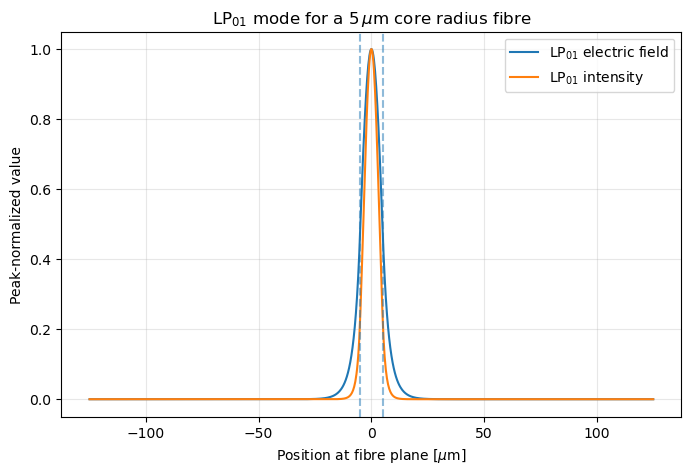

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_LP01_1d * 1e6,
    E_LP01_1d_plot,
    label=r"LP$_{01}$ electric field",
)

plt.plot(
    x_LP01_1d * 1e6,
    I_LP01_1d_plot,
    label=r"LP$_{01}$ intensity",
)

plt.axvline(-a * 1e6, linestyle="--", alpha=0.5)
plt.axvline(a * 1e6, linestyle="--", alpha=0.5)

plt.xlabel(r"Position at fibre plane [$\mu$m]")
plt.ylabel("Peak-normalized value")
plt.title(r"LP$_{01}$ mode for a $5\,\mu$m core radius fibre")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_3959/3922114278.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


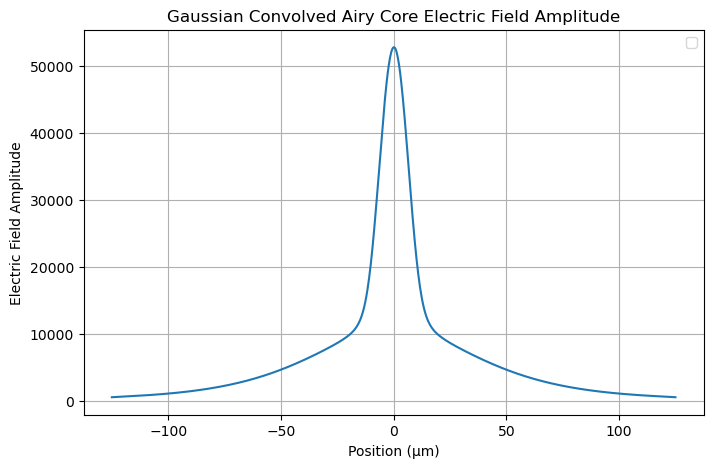

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(x_1d * 1e6, E_AO_1d)  # Convert x_1d to micrometers for better visualization
plt.xlabel("Position (μm)")
plt.ylabel("Electric Field Amplitude")
plt.title("Gaussian Convolved Airy Core Electric Field Amplitude")
plt.legend()
plt.grid(True)
plt.show()

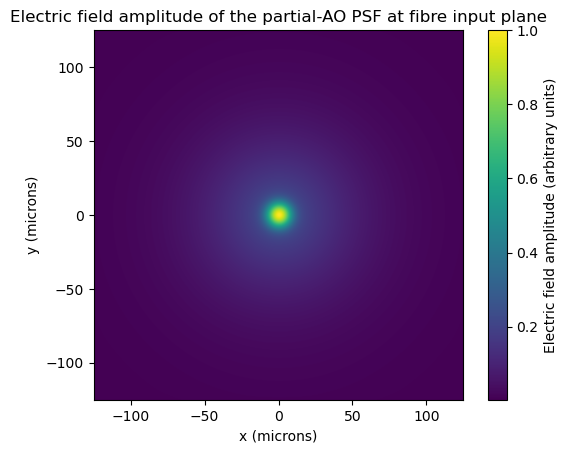

In [56]:
E_AO_final_2d = np.sqrt(I_AO_final / np.max(I_AO_final)) # Normalize the final AO PSF intensity to its maximum before taking the square root to get the amplitude. This is for visualization purposes, as the absolute scale of the electric field amplitude is arbitrary in this context.
plt.imshow(E_AO_final_2d, extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6), origin='lower')
plt.xlabel('x (microns)')
plt.ylabel('y (microns)')
plt.title('Electric field amplitude of the partial-AO PSF at fibre input plane')
plt.colorbar(label='Electric field amplitude (arbitrary units)')
plt.show()

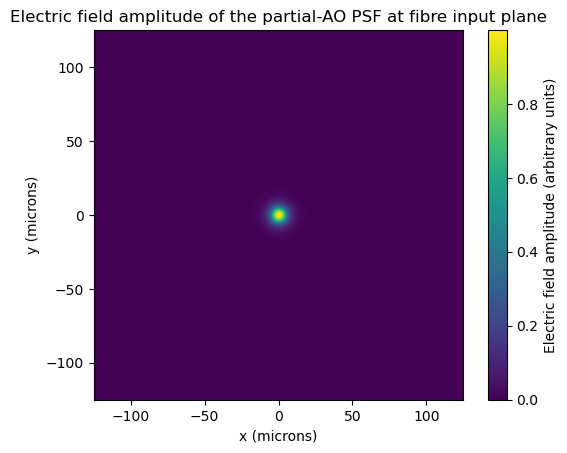

In [57]:
plt.imshow(E_LP01_2d, extent=(x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6), origin='lower')
plt.xlabel('x (microns)')
plt.ylabel('y (microns)')
plt.title('Electric field amplitude of the partial-AO PSF at fibre input plane')
plt.colorbar(label='Electric field amplitude (arbitrary units)')
plt.show()

In [58]:
eta_jittered, numerator_jittered, denominator_jittered = coupling_efficiency_2d(E_core_jittered, E_LP01_2d, x_1d, y_1d)
print(f"Coupling efficiency into LP01 mode: {eta_jittered:.6f}")
print(numerator_jittered, denominator_jittered)

Coupling efficiency into LP01 mode: 0.748848
2.832867510029706e-22 3.782966020770615e-22


### Residual tip--tilt jitter and fibre coupling

#### 1. What is pointing jitter?

Residual tip--tilt jitter is a small, time-dependent change in the direction of the science beam after imperfect telescope guiding or adaptive-optics correction.

At the focal plane, this angular variation causes the point-spread function to move around its nominal position.

For angular tip--tilt components $\theta_x(t)$ and $\theta_y(t)$, the corresponding focal-plane displacements are

$$
\Delta x(t) = f_{\mathrm{eff}}\theta_x(t),
\qquad
\Delta y(t) = f_{\mathrm{eff}}\theta_y(t),
$$

where the angles are expressed in radians.

For pure tip--tilt, the instantaneous PSF does not become intrinsically wider. Instead, the entire Airy pattern is displaced:

$$
E(x,y,t) = E_0\left[x-\Delta x(t),\,y-\Delta y(t)\right].
$$

The central Airy lobe, the outer rings, and the phase reversals between the rings all move together.

#### 2. Why approximate jitter with a Gaussian?

The image position changes continuously during an exposure. A simple approximation is to assume that the horizontal and vertical displacements follow independent Gaussian distributions:

$$
\Delta x \sim \mathcal{N}(0,\sigma_{\mathrm{jitter}}^2),
\qquad
\Delta y \sim \mathcal{N}(0,\sigma_{\mathrm{jitter}}^2).
$$

The corresponding two-dimensional probability density is

$$
p(\Delta x,\Delta y)
=
\frac{1}{2\pi\sigma_{\mathrm{jitter}}^2}
\exp\left[
-\frac{\Delta x^2+\Delta y^2}
{2\sigma_{\mathrm{jitter}}^2}
\right].
$$

This Gaussian is not an electric field. It describes how likely the PSF is to have each displacement from its nominal position.

#### 3. Why convolve the intensity?

A detector records intensity rather than electric-field amplitude. During a long exposure, it records the average of many shifted intensity PSFs:

$$
I_{\mathrm{long}}(x,y)
=
\left\langle
I_0\left[x-\Delta x(t),\,y-\Delta y(t)\right]
\right\rangle.
$$

Using the Gaussian probability distribution, this becomes

$$
I_{\mathrm{long}}(x,y)
=
\iint
I_0(x-\Delta x,y-\Delta y)
p(\Delta x,\Delta y)
\,d\Delta x\,d\Delta y.
$$

This is a convolution:

$$
I_{\mathrm{long}} = I_0 * p.
$$

Therefore, the long-exposure jitter-broadened Airy intensity can be approximated by

$$
I_{\mathrm{Airy,jittered}}
=
I_{\mathrm{Airy}} * G_{\mathrm{jitter}}.
$$

This broadens the central peak and smooths the Airy rings.

#### 4. Why not use the convolved intensity for the fibre overlap?

Single-mode fibre coupling depends on both the electric-field amplitude and phase:

$$
\eta
=
\frac{
\left|
\iint
E_{\mathrm{input}}(x,y)
E_{\mathrm{LP01}}^*(x,y)
\,dx\,dy
\right|^2
}{
\left(
\iint |E_{\mathrm{input}}|^2\,dx\,dy
\right)
\left(
\iint |E_{\mathrm{LP01}}|^2\,dx\,dy
\right)
}.
$$

The Airy electric field contains positive and negative regions. These correspond to phase changes of $\pi$ between successive Airy rings.

The intensity

$$
I_{\mathrm{Airy}} = |E_{\mathrm{Airy}}|^2
$$

does not retain this sign or phase information.

Therefore, the jitter-broadened intensity is useful for plotting the long-exposure PSF, but it cannot be converted back into a unique physical electric field for the overlap integral.

#### 5. Electric-field treatment for fibre coupling

For each possible jitter displacement, the signed Airy electric field is shifted:

$$
E_{\Delta}(x,y)
=
E_{\mathrm{Airy}}(x-\Delta x,y-\Delta y).
$$

The coupling efficiency is calculated for that displacement:

$$
\eta(\Delta x,\Delta y)
=
\eta\left[E_{\Delta},E_{\mathrm{LP01}}\right].
$$

The mean coupling efficiency is then obtained by averaging over the Gaussian displacement distribution:

$$
\left\langle\eta\right\rangle
=
\iint
p(\Delta x,\Delta y)
\eta(\Delta x,\Delta y)
\,d\Delta x\,d\Delta y.
$$

The numerical procedure is:

1. Generate a jitter displacement $(\Delta x,\Delta y)$.
2. Shift the signed Airy electric field.
3. Calculate its overlap with the LP$_{01}$ fibre mode.
4. Calculate the coupling efficiency.
5. Repeat for many displacements.
6. Average the coupling efficiencies.

This preserves the phase information in the Airy field.

#### 6. Converting the assumed VLT jitter to the fibre plane

Assume an angular RMS jitter of

$$
\sigma_{\theta} = 20~\mathrm{mas}.
$$

Convert this to radians:

$$
\sigma_{\theta,\mathrm{rad}}
=
\frac{20\times10^{-3}}{206265}.
$$

At the native Coudé focal plane,

$$
\sigma_{\mathrm{Coud\acute{e}}}
=
f_{\mathrm{Coud\acute{e}}}
\sigma_{\theta,\mathrm{rad}}.
$$

If the native Coudé image is demagnified by

$$
M = 0.1,
$$

then the RMS displacement at the fibre plane is

$$
\sigma_{\mathrm{fibre}}
=
M f_{\mathrm{Coud\acute{e}}}
\sigma_{\theta,\mathrm{rad}}.
$$

Using

$$
f_{\mathrm{Coud\acute{e}}} = 378.4~\mathrm{m},
$$

gives

$$
\sigma_{\mathrm{fibre}}
\approx
3.67~\mu\mathrm{m}.
$$

If the final fibre focal ratio already includes the re-imaging optics, the same displacement can be calculated from

$$
\sigma_{\mathrm{fibre}}
=
F_{\mathrm{fibre}}
D_{\mathrm{tel}}
\sigma_{\theta,\mathrm{rad}}.
$$

The demagnification factor should only be included once.

#### 7. Modelling choice

For visualising the long-exposure PSF, use intensity convolution:

$$
I_{\mathrm{Airy,jittered}}
=
I_{\mathrm{Airy}} * G_{\mathrm{jitter}}.
$$

For calculating single-mode fibre coupling, use displaced electric fields:

$$
\left\langle\eta\right\rangle
=
\left\langle
\eta\left[
E_{\mathrm{Airy}}(x-\Delta x,y-\Delta y),
E_{\mathrm{LP01}}
\right]
\right\rangle.
$$

The assumed $20~\mathrm{mas}$ value is treated as an approximate RMS residual jitter for testing the sensitivity of the fibre coupling.
```


In [97]:
def prepare_modes_2d(
    x, y,
    a, NA, lam0,
    az_sym=True,
    mode_case="few_mode"
):
    """
    Prepare fibre mode fields for a fixed core radius.

    Parameters:
    x, y: 2D coordinate arrays at the fibre input plane [m]
    a: Core radius of the fibre [m]
    NA: Numerical aperture of the fibre
    lam0: Wavelength [m]
    az_sym: If True, only include azimuthally symmetric modes (l=0). If False, 
    include all modes up to l_max.
    mode_case:
        "smf"      -> only LP01
        "few_mode" -> all supported modes, optionally restricted by az_sym
    
    Returns value: 
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    Includes l, m, cutoff_V, X_root, Y_root, angular, E_mode, I_mode for each mode.
    """

    V = 2 * np.pi * a * NA / lam0

    if mode_case == "smf": # note if the maximum radius leads to V > 2.405, the fibre would support more modes, the case would be impractical
        allmodes = [[0, 1, 0.0]]
        if V > 2.405:
            print(f"Warning: V={V:.3f} > 2.405, the fibre would support more modes than just LP01, the 'smf' case may be impractical.")

    elif mode_case == "few_mode":
        allmodes = modes(V, az_sym_only=az_sym) # compute all modes supported by the fibre based on the V number

        if az_sym:
            allmodes = [mode for mode in allmodes if mode[0] == 0] # only keep azimuthally symmetric modes if az_sym is True

    else:
        raise ValueError("mode_case must be 'smf' or 'few_mode'")

    # Create a list to store the prepared modes
    prepared_modes = []
    # Loop through each mode created from modes() and compute the corresponding electric field distribution
    for mode in allmodes:
        l, m, cutoff_V = mode

        try:
            X_root, Y_root = find_root_XY(l, m, V) # find X_root and Y_root for the mode with l,m, at the given V estimated from a (not Vc)
        except ValueError:
            continue

        if l == 0:
            angular_list = ["cos"] # only one polarisaton for azimuthally symmetric modes, technically for l=0 the angular part is just a constant (cos(0)=1)
        else:
            angular_list = ["cos", "sin"] # both cos and sin polarisations for asymmetric modes

        for angular in angular_list:
            E_mode, I_mode = lp_mode_field_2d(
                x, y,
                a=a,
                l=l,
                X_root=X_root,
                Y_root=Y_root,
                angular=angular
            )

            prepared_modes.append({
                "l": l,
                "m": m,
                "cutoff_V": cutoff_V,
                "X_root": X_root,
                "Y_root": Y_root,
                "angular": angular,
                "E_mode": E_mode,
                "I_mode": I_mode
            })

    return prepared_modes

In [98]:
def total_eff_2d(
    prepared_modes,
    x, y, x_1d, y_1d,
    lam0, F_eff, alpha,
    decentre=None,
    E_S=1.0
):
    """
    Calculates the total 2D coupling efficiency using precomputed fibre modes.
    Only E_image changes with focal ratio F.

    Parameters:
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    x, y: 2D coordinate arrays at the fibre input plane [m]
    x_1d, y_1d: 1D coordinate arrays used to make the 2D grid [m]
    lam0: Wavelength [m]
    F_eff: Effective focal ratio to be optimised
    alpha: Divergence angle [rad]
    decentre: Decentre of the image field [m]
    E_S: Source electric field amplitude [V/m]
    """

    E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_eff,
        alpha=alpha,
        E_S=E_S,
        decentre=decentre
    )

    # begin with zero efficiency when we haven't started accumulating eta for any modes
    total = 0.0
    mode_results = [] # array of dictionaries containing mode results

    # for each existing modes in the prepared_modes list, calculate eta at that mode
    for mode in prepared_modes:
        eta, num, den = coupling_efficiency_2d(
            E_image,
            mode["E_mode"],
            x_1d,
            y_1d
        )

        total += eta # accumulate coupling efficiency at each mode to the total coupling efficiency

        mode_results.append({
            "l": mode["l"],
            "m": mode["m"],
            "cutoff_V": mode["cutoff_V"],
            "X_root": mode["X_root"],
            "Y_root": mode["Y_root"],
            "angular": mode["angular"],
            "eta": eta
        })

    return total, mode_results

In [99]:
def eta_psf_vs_decentre_position_2d(
        prepared_modes, 
        x, y, x_1d, y_1d, 
        lam0, F_eff, alpha, 
        decentre_array, 
        E_S = 1.0, 
        direction_angle = 0.0
):
    """
    Calculate the coupling efficiency of a point source  as a function to its decentre relative 
    to the fibre. 

    Parameters: 
    prepared_modes: the pre-computed fibre modes containing eigenfield information for ONE core radius

    decentre_array: array of image positions relative to the fibre centre

    direction_angle: the angle of offset direction in the x-y grid plane
    Assuming angle is zero for a circularly symmetric aperature
    """

    eta_psf = [] # prepare array of eta_psf for each decentre coordinate
    mode_results_all = [] # not required but returns the fields of eigenmodes

    for r in decentre_array: # r is distance to centre
        dx = r * np.cos(direction_angle) # cos(0)=1, we are varying in the x direction
        dy = r * np.sin(direction_angle) # sin(0)=0 

        eta_total, mode_results = total_eff_2d(
            prepared_modes, 
            x, y, x_1d, y_1d, 
            lam0=lam0, 
            F_eff=F_eff, 
            alpha=alpha, 
            decentre=(dx, dy),
            E_S=E_S
        )

        eta_psf.append(eta_total)
        mode_results_all.append(mode_results)

    eta_psf = np.array(eta_psf)

    return eta_psf, mode_results_all


## Compute the $\eta$ for offset E-field, repeat for different offsets distributed probabilistically

Reyleigh probability density can be used in place of normal density distribution if I only need to calculate the pdf of displacement distribution in the radial direction, assuming that the Airy function 

### Rayleigh probability density for radial jitter

The residual tip--tilt is assumed to have independent Gaussian components in the two Cartesian directions:

$$
\Delta x \sim \mathcal{N}(0,\sigma^2),
\qquad
\Delta y \sim \mathcal{N}(0,\sigma^2).
$$

The radial displacement from the fibre centre is

$$
r = \sqrt{\Delta x^2+\Delta y^2}.
$$

When $\Delta x$ and $\Delta y$ are independent zero-mean Gaussian variables with the same standard deviation $\sigma$, the radial displacement $r$ follows a Rayleigh distribution:

$$
p(r)
=
\frac{r}{\sigma^2}
\exp\left(
-\frac{r^2}{2\sigma^2}
\right),
\qquad
r \geq 0.
$$

Here:

- $r$ is the radial displacement of the point-source field from the fibre centre;
- $\sigma$ is the one-axis RMS jitter, so that $\sigma_x=\sigma_y=\sigma$;
- $p(r)$ is the probability density per unit radial displacement.

The probability density is normalized such that

$$
\int_0^\infty p(r)\,dr = 1.
$$

The radial RMS displacement is

$$
r_{\mathrm{RMS}}
=
\sqrt{\left\langle r^2\right\rangle}
=
\sqrt{2}\,\sigma.
$$

Therefore, $\sigma$ in the Rayleigh distribution is not the radial RMS. It is the RMS displacement in either the $x$ or $y$ direction.

In [100]:
def rayleigh_pdf(radial_offset, sigma):
    """
    Rayleigh probability density for radial jitter.

    Parameters
    ----------
    radial_offset : array-like
        Radial displacement [m].

    sigma : float
        One-axis RMS jitter at the fibre plane [m].

    Returns
    -------
    pdf : ndarray
        Radial probability density [1/m].
    """ 

    # convert to numpy array
    radial_offset = np.asarray(radial_offset, dtype=float) 

    # Radial probablity density

    pdf = radial_offset / sigma**2 * np.exp(-radial_offset**2 / (2.0 * sigma**2))

    return pdf



### Mean fibre coupling in the presence of radial jitter

Because the Airy field and the $LP_{01}$ fibre mode are assumed to be radially symmetric, the coupling efficiency depends only on the radial separation $r$ between their centres:

$$
\eta(\Delta x,\Delta y) = \eta(r).
$$

The mean coupling efficiency is found by weighting the coupling at each radial displacement by the Rayleigh probability density:

$$
\left\langle\eta\right\rangle
=
\int_0^\infty
\eta(r)\,p(r)\,dr.
$$

Substituting the Rayleigh probability density gives

$$
\left\langle\eta\right\rangle
=
\int_0^\infty
\eta(r)
\frac{r}{\sigma^2}
\exp\left(
-\frac{r^2}{2\sigma^2}
\right)
\,dr.
$$

In the numerical model, the integral is evaluated over a finite radial range from $0$ to $r_{\max}$:

$$
\left\langle\eta\right\rangle_{\mathrm{numerical}}
=
\frac{
\displaystyle
\int_0^{r_{\max}}
\eta(r)\,p(r)\,dr
}{
\displaystyle
\int_0^{r_{\max}}
p(r)\,dr
}.
$$

The denominator corrects for the small amount of probability outside the finite radial grid.

For a maximum radius of

$$
r_{\max}=5\sigma,
$$

the captured probability is

$$
P(r\leq5\sigma)
=
1-\exp\left(-\frac{25}{2}\right),
$$

which is very close to one.

The coupling curve $\eta(r)$ is calculated by shifting the point-source electric field by a distance $r$ along one direction:

$$
E_r(x,y)
=
E_{\mathrm{Airy}}(x-r,y).
$$

Only one direction is required because, under the radial-symmetry assumption, all offsets with the same magnitude $r$ produce the same coupling efficiency.

In [139]:
def average_eta_over_rayleigh_jitter(decentre_array, eta_psf_array, sigma_jitter): 
    """
    Average coupling efficiency over an isotropic jitter distribution. 

    Parameters
    ----------
    decentre_array : 1D ndarray
        Radial offsets used to calculate eta_psf_array [m].

    eta_psf_array : 1D ndarray
        Coupling efficiency at each radial offset.

    sigma_jitter : float
        One-axis RMS jitter at the fibre plane, in units of metres!!!

    Returns 
    -------
    eta_mean: float
        Mean coupling efficiency, averaged by the Rayleigh jitter distribution. 
    
    probability_captured: float 
        Probability that the PSF is contained within the finite offset range of decentre_array 
    
    probability_density: n array
        The Rayleigh probability density evaluated at decentre_array, used for weighting the average.

    """

    # Calculate the Rayleigh probability density at each radial offset
    probability_density = rayleigh_pdf(radial_offset=decentre_array, sigma=sigma_jitter)

    # The numerator of the weighted average is the integral of eta_psf_array * probability_density over decentre_array
    eta_weighted = np.trapezoid(eta_psf_array * probability_density, x=decentre_array) 

    # The denominator of the weighted average is the integral of the Rayleigh PDF over decentre_array
    probability_captured = np.trapezoid(probability_density, x=decentre_array)

    # eta_mean is the weighted average normlalised by the total probability captured within the finite range of decentre_array
    eta_mean = eta_weighted / probability_captured

    return eta_mean, eta_weighted, probability_captured, probability_density


In [140]:
# np.trapezoid?

In [141]:
prepared_modes = prepare_modes_2d(
    x=x,
    y=y,
    a=a,
    NA=NA,
    lam0=lam0,
    az_sym=True,
    mode_case="smf",
)

In [142]:
49.9*8

399.2

In [143]:
# convert the jitter FWHM to sigma for the Rayleigh distribution
jitter_rms_mas = 20

sigma_theta_rad = jitter_rms_mas * 1e-3 / 206265

f_coude = 399 

M_reimage = 5 / 49.9 

sigma_jitter_fibre = M_reimage * f_coude * sigma_theta_rad

print(
    f"One-axis RMS jitter at fibre plane: "
    f"{sigma_jitter_fibre * 1e6:.4f} µm"
)


One-axis RMS jitter at fibre plane: 3.8766 µm


In [144]:
# # five standard deviations of the jitter distribution (Rayleigh distribution assuming radial symmetry, 
# # so 5 sigma in the radial direction would correspond to 5 sigma in the x and y directions as well)
# max_sigma = 5.0 

# # The probability that PSF is captured within 5 sigma is 1 - the probablity the PSF is outside 5 sigma
# probability_captured_exact = 1.0 - np.exp(-0.5 * max_sigma**2)

# # Probability that the PSF is outside 5 sigma, which is the tail probability of the Rayleigh distribution beyond 5 sigma
# probability_outside = np.exp(-0.5 * max_sigma**2)

# print(
#     f"Probability captured: "
#     f"{probability_captured_exact:.10f}"
# )

# print(
#     f"Probability outside grid: "
#     f"{probability_outside:.10e}"
# )

In [145]:
# define radial displacements
max_sigma = 5.0
n_decentre = 200

# define the decentre array in metres, from 0 to max_sigma * sigma_jitter_fibre
decentre_array = np.linspace(0.0, max_sigma * sigma_jitter_fibre, n_decentre)


In [147]:
eta_psf, mode_results_decentre = eta_psf_vs_decentre_position_2d(prepared_modes=prepared_modes, x=x, y=y, x_1d=x_1d, y_1d=y_1d, 
                                                                 lam0=lam0, F_eff=F_fibre, alpha=alpha, 
                                                                 decentre_array=decentre_array, E_S=1.0, direction_angle=0.0)

In [148]:
jitter_pdf = rayleigh_pdf(decentre_array, sigma_jitter_fibre) 
weighted_coupling = eta_psf * jitter_pdf

In [149]:
# average coupling efficiency over the jitter distribution
eta_jittered_mean, eta_weighted_jittered, probability_captured, probability_density = average_eta_over_rayleigh_jitter(decentre_array, eta_psf, sigma_jitter_fibre)

In [150]:
print(f"Probability captured: {probability_captured:.10f}")
print(f"Mean LP01 coupling with jitter: {eta_jittered_mean:.6f}")

Probability captured: 0.9999436589
Mean LP01 coupling with jitter: 0.377351


In [153]:
eta_weighted_jittered

np.float64(0.37733000190256244)

In [154]:
probability_captured

np.float64(0.9999436588827483)

In [151]:
eta_psf[0]

np.float64(0.763019595911316)

In [152]:
eta_centred = eta_psf[0]

relative_coupling = eta_jittered_mean / eta_centred
fractional_loss = 1.0 - relative_coupling

print(f"Centred coupling: {eta_centred:.6f}")
print(f"Mean jittered coupling: {eta_jittered_mean:.6f}")
print(f"Relative coupling: {relative_coupling:.6f}")
print(f"Fractional coupling loss: {fractional_loss:.6f}")

Centred coupling: 0.763020
Mean jittered coupling: 0.377351
Relative coupling: 0.494550
Fractional coupling loss: 0.505450


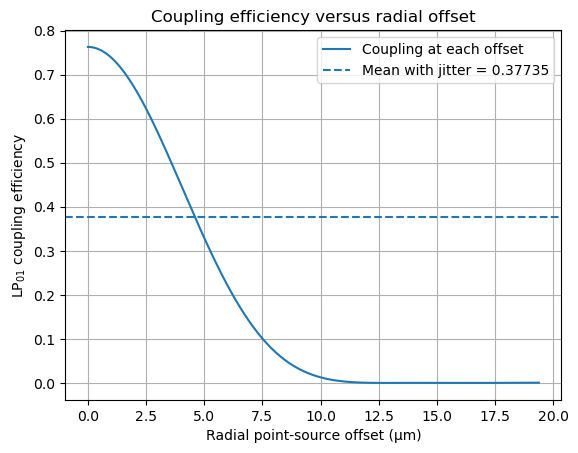

In [155]:
plt.figure()

plt.plot(
    decentre_array * 1e6,
    eta_psf,
    label="Coupling at each offset"
)

plt.axhline(
    eta_jittered_mean,
    linestyle="--",
    label=f"Mean with jitter = {eta_jittered_mean:.5f}"
)

plt.xlabel("Radial point-source offset (µm)")
plt.ylabel("LP$_{01}$ coupling efficiency")
plt.title("Coupling efficiency versus radial offset")

plt.grid()
plt.legend()
plt.show()

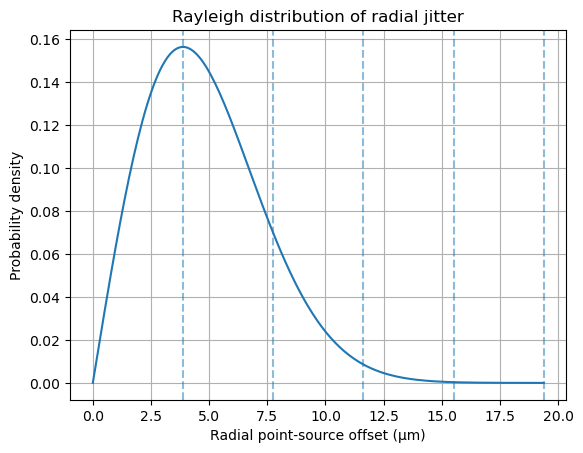

In [162]:
plt.figure()

plt.plot(
    decentre_array * 1e6,
    jitter_pdf * 1e-6
)

# plot sigma=1,2,3,4,5 lines for reference
for n in range(1, 6):
    plt.axvline(
        n * sigma_jitter_fibre * 1e6,
        linestyle="--",
        alpha=0.5,
        label=f"{n}σ"
    )

plt.xlabel("Radial point-source offset (µm)")
plt.ylabel("Probability density")
plt.title("Rayleigh distribution of radial jitter")

plt.grid()
plt.show()

In [157]:
# define radial displacements
max_sigma = 5.0
n_decentre_2000 = 2000

# define the decentre array in metres, from 0 to max_sigma * sigma_jitter_fibre
decentre_array_2000 = np.linspace(0.0, max_sigma * sigma_jitter_fibre, n_decentre_2000)

In [158]:
eta_psf_test, mode_results_decentre_test = eta_psf_vs_decentre_position_2d(prepared_modes=prepared_modes, x=x, y=y, x_1d=x_1d, y_1d=y_1d, 
                                                                 lam0=lam0, F_eff=F_fibre, alpha=alpha, 
                                                                 decentre_array=decentre_array_2000, E_S=1.0, direction_angle=0.0)

In [159]:
jitter_pdf_test = rayleigh_pdf(decentre_array_2000, sigma_jitter_fibre) 
weighted_coupling_test = eta_psf_test * jitter_pdf_test
eta_jittered_mean_test, eta_weighted_jittered_test, probability_captured_test, probability_density_test = average_eta_over_rayleigh_jitter(decentre_array_2000, eta_psf_test, sigma_jitter_fibre)


In [160]:
print(f"Probability captured: {probability_captured_test:.10f}")
print(f"Mean LP01 coupling with jitter: {eta_jittered_mean_test:.6f}")

Probability captured: 0.9999957519
Mean LP01 coupling with jitter: 0.377371


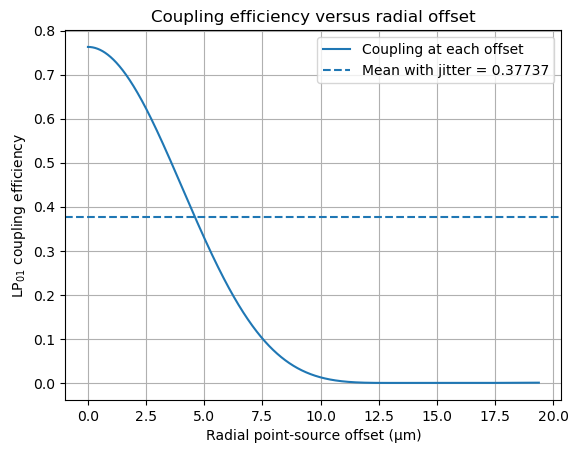

In [161]:
plt.figure()

plt.plot(
    decentre_array_2000 * 1e6,
    eta_psf_test,
    label="Coupling at each offset"
)

plt.axhline(
    eta_jittered_mean_test,
    linestyle="--",
    label=f"Mean with jitter = {eta_jittered_mean_test:.5f}"
)

plt.xlabel("Radial point-source offset (µm)")
plt.ylabel("LP$_{01}$ coupling efficiency")
plt.title("Coupling efficiency versus radial offset")

plt.grid()
plt.legend()
plt.show()